In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install roboflow ultralytics ipython opencv-python numpy pandas matplotlib seaborn tqdm pyyaml


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 14.0 MB/s eta 0:00:00
Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   -------------------- ------------------- 19.7/38.8 MB 103.7 MB/s eta 0:00:01
   ---------------------------------------  38.5/38.8 MB 111.3 MB/s eta 0:00:01
   --------------------------------

In [3]:
# Reinstala PyTorch con soporte CUDA (cu130) en el mismo Python del kernel
import sys
print('Kernel Python:', sys.executable)
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip cache purge
!{sys.executable} -m pip install --index-url https://download.pytorch.org/whl/cu130 torch torchvision torchaudio --upgrade
print('Instalación finalizada. Reinicia el kernel y ejecuta la celda de verificación.')


Kernel Python: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Found existing installation: torchvision 0.25.0
Uninstalling torchvision-0.25.0:
  Successfully uninstalled torchvision-0.25.0


Files removed: 541 (534.1 MB)
Directories removed: 15
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu130
   ---------------------------------------- 0.0/1.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 GB 75.1 MB/s eta 0:00:25
    --------------------------------------- 0.0/1.9 GB 99.5 MB/s eta 0:00:19
   - -------------------------------------- 0.1/1.9 GB 107.5 MB/s eta 0:00:17
   - -------------------------------------- 0.1/1.9 GB 107.7 MB/s eta 0:00:17
   -- ------------------------------------- 0.1/1.9 GB 110.8 MB/s eta 0:00:16
   -- ------------------------------------- 0.1/1.9 GB 110.5 MB/s eta 0:00:16
   --- ------------------------------------ 0.2/1.9 GB 112.1 MB/s eta 0:00:16
   --- ------------------------------------ 0.2/1.9 GB 110.8 MB/s eta 0:00:16
   ---- ----------------------------------- 0.2/1.9 GB 110.7 MB/s eta 0:00:16
   ---- --------------------------------

In [4]:
# Diagnóstico rápido del entorno y de los imports
import sys, subprocess, importlib, traceback

print("Python:", sys.executable)
print("Version:", sys.version.replace('\\n', ' '))
print("sys.path (primeros 5):", sys.path[:5])

def show_pkg(name):
    print("\\n==", name, "==")
    try:
        subprocess.run([sys.executable, "-m", "pip", "show", name], check=False)
    except Exception as e:
        print("pip show error:", e)
    try:
        spec = importlib.util.find_spec(name)
        print("find_spec:", spec)
    except Exception as e:
        print("find_spec error:", e)
    try:
        m = importlib.import_module(name)
        v = getattr(m, '__version__', None)
        print("Imported OK, version:", v)
    except Exception as e:
        print("Import error for", name, ":", type(e).__name__, e)
        traceback.print_exc()

for pkg in ("ultralytics","roboflow","torch","IPython","cv2"):
    show_pkg(pkg)

Python: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
sys.path (primeros 5): ['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\\python312.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0', '']
\n== ultralytics ==
find_spec: ModuleSpec(name='ultralytics', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001A516971850>, origin='C:\\Users\\User\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\ultralytics\\__init_

In [5]:
from ultralytics import YOLO
from IPython.display import Image
from roboflow import Roboflow
import torch

```
pip install ultralytics
pip install roboflow 
pip install opencv-python # for the next purpose
pip install ipython
```

In [8]:
import sys, os, subprocess
print("sys.executable:", sys.executable)
print("Python version:", sys.version.replace('\\n',' '))
print("\n--- pip show torch ---")
subprocess.run([sys.executable, "-m", "pip", "show", "torch"])
print("\n--- torch info ---")
import importlib, traceback
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", getattr(torch.version, 'cuda', None))
    print("torch.__file__:", getattr(torch, '__file__', None))
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA device count:", torch.cuda.device_count())
    try:
        if torch.cuda.device_count() > 0:
            print("Device name:", torch.cuda.get_device_name(0))
    except Exception as e:
        print("get_device_name error:", e)
    print("cuDNN available:", getattr(torch.backends, 'cudnn', None) and torch.backends.cudnn.is_available())
except Exception as e:
    print("Error importing torch:", type(e).__name__, e)
    traceback.print_exc()

print("\nCUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("\n--- nvidia-smi desde kernel ---")
!nvidia-smi

sys.executable: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

--- pip show torch ---

--- torch info ---
torch.__version__: 2.10.0+cu130
torch.version.cuda: 13.0
torch.__file__: C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\__init__.py
CUDA available: True
CUDA device count: 1
Device name: NVIDIA GeForce MX110
cuDNN available: True

CUDA_VISIBLE_DEVICES: None

--- nvidia-smi desde kernel ---
Wed Mar  4 17:13:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driv

In [9]:
torch.cuda.is_available()

True

In [10]:
import CFG

In [11]:
# Comprobación de API_KEY: origen y estado (env o archivo)
import os
import importlib.util
source = 'none'
if os.environ.get('API_KEY'):
    source = 'env'
elif importlib.util.find_spec('Api_key') is not None:
    source = 'file Api_key.py'
else:
    source = 'missing'
print('API_KEY source:', source)
try:
    import CFG
    val = getattr(CFG, 'API_KEY', None)
    if not val:
        print('CFG.API_KEY: None or empty')
    else:
        s = str(val)
        masked = (s[:4] + '...' + s[-4:]) if len(s) > 8 else '***'
        print('CFG.API_KEY loaded (masked):', masked, ' length=', len(s))
except Exception as e:
    print('Error importing CFG:', e)

API_KEY source: file Api_key.py
CFG.API_KEY loaded (masked): bPfp...WL9k  length= 20


In [12]:
rf = Roboflow(api_key="bPfpYnG7o1802h2lWL9k")
project = rf.workspace("waza17").project("demo_emotions-ovmnn")
version = project.version(2)
dataset = version.download("yolov8")               

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to demo_Emotions-2 in yolov8:: 100%|██████████| 718/718 [00:00<00:00, 1118.27it/s]


In [13]:
data_path = dataset.location + "/data.yaml"

In [ ]:
!yolo task=detect mode=train model=yolov8n.pt data={data_path} epochs=40 imgsz=353 batch=8 device=cpu name=train7

Ultralytics 8.4.19  Python-3.12.10 torch-2.10.0+cu130 CPU (Intel Core i5-8250U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\User\yolo-emotion-detector\demo_Emotions-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=353, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [39]:
!yolo val model=runs/detect/train7/weights/best.pt plots=True

WARNING 'data' argument is missing. Using default 'data=coco8.yaml'.
Ultralytics 8.4.19  Python-3.12.10 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce MX110, 2048MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

WARNING Dataset 'coco8.yaml' images not found, missing path 'C:\Users\User\yolo-emotion-detector\datasets\coco8\images\val'


Unzipping C:\Users\User\yolo-emotion-detector\datasets\coco8.zip to C:\Users\User\yolo-emotion-detector\datasets\coco8...: 100% ━━━━━━━━━━━━ 25/25 1.3Kfiles/s 0.0s
Dataset download success  (0.6s), saved to C:\Users\User\yolo-emotion-detector\datasets

val: Fast image access  (ping: 0.10.0 ms, read: 7.24.1 MB/s, size: 54.0 KB)

val: Scanning C:\Users\User\yolo-emotion-detector\datasets\coco8\labels\val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 164.7it/s 0.0s
val: New cache created: C:\Users\User\yolo-emotion-detector\datasets\coco8\labels\val.cache


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce MX110 which is of cuda capability 5.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.5) - (12.0)
    
  queued_call()
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\cuda\__init__.py:435: UserWarning: 
NVIDIA GeForce MX110 with CUDA capability sm_50 is not compatible with the current PyTorch installation.

Contents of runs/detect/train7
runs/detect/train7\args.yaml
runs/detect/train7\BoxF1_curve.png
runs/detect/train7\BoxPR_curve.png
runs/detect/train7\BoxP_curve.png
runs/detect/train7\BoxR_curve.png
runs/detect/train7\confusion_matrix.png
runs/detect/train7\confusion_matrix_normalized.png
runs/detect/train7\labels.jpg
runs/detect/train7\results.csv
runs/detect/train7\results.png
runs/detect/train7\train_batch0.jpg
runs/detect/train7\train_batch1.jpg
runs/detect/train7\train_batch1170.jpg
runs/detect/train7\train_batch1171.jpg
runs/detect/train7\train_batch1172.jpg
runs/detect/train7\train_batch2.jpg
runs/detect/train7\val_batch0_labels.jpg
runs/detect/train7\val_batch0_pred.jpg
runs/detect/train7\val_batch1_labels.jpg
runs/detect/train7\val_batch1_pred.jpg
runs/detect/train7\weights\best.pt
runs/detect/train7\weights\last.pt


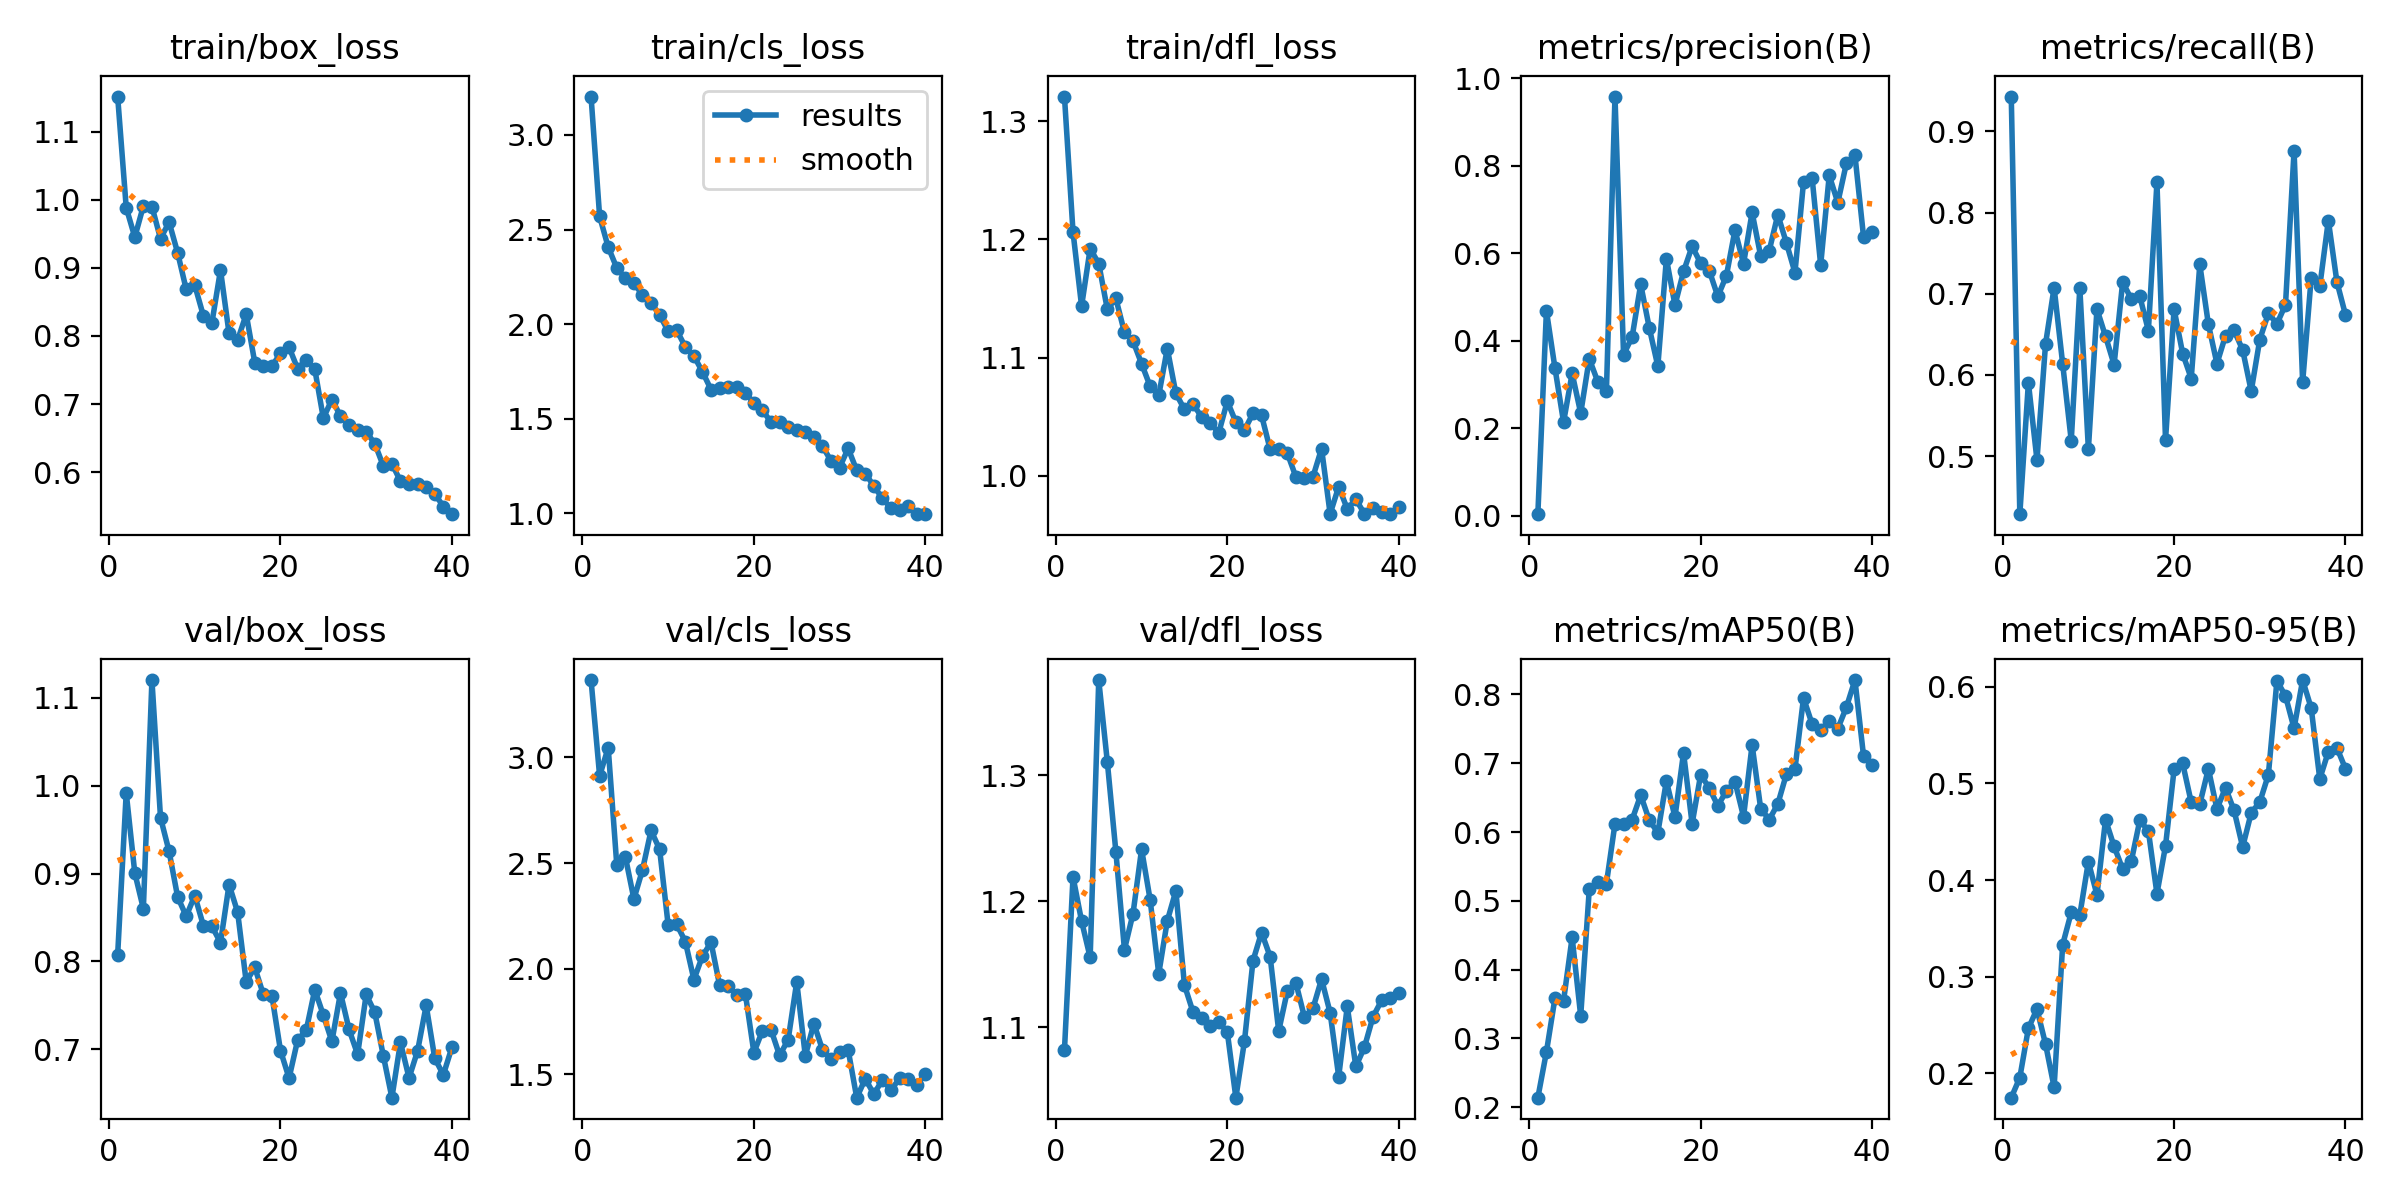

In [37]:
import os
run_folder = 'runs/detect/train7'
print('Contents of', run_folder)
for root, dirs, files in os.walk(run_folder):
    for f in files:
        print(os.path.join(root, f))

# show training plots if available
plot_path = os.path.join(run_folder, 'results.png')
if os.path.exists(plot_path):
    display(Image(filename=plot_path))
else:
    print('No results.png found yet, training may not have completed or saved plots.')

In [38]:
Image(filename='runs/detect/val/confusion_matrix.png')

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/val/confusion_matrix.png'